In [1]:
# 02 - Data Quality Validation

"""This notebook validates the quality of the cleaned e-commerce price dataset before performing statistical analysis.

Main checks:
- Missing values
- Duplicate records
- Invalid prices
- Date consistency
- Category and site consistency
- Time-series coverage per product"""

'This notebook validates the quality of the cleaned e-commerce price dataset before performing statistical analysis.\n\nMain checks:\n- Missing values\n- Duplicate records\n- Invalid prices\n- Date consistency\n- Category and site consistency\n- Time-series coverage per product'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
## Load Data from BigQuery

In [4]:
# Parameters

PROJECT_ID = "price-intel-prod"
DATASET_ID = "price_staging"
RUN_DATE = "manual_run"
OUTPUT_DIR = "../reports"

In [5]:
# Parameters
PROJECT_ID = "price-intel-prod"
DATASET_ID = "price_staging"
RUN_DATE = "2026-06-11"
OUTPUT_DIR = "reports"


In [6]:
client = bigquery.Client(project=PROJECT_ID)

C:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [7]:
query_clean = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.clean_prices`
"""

query_ts = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.price_timeseries`
"""

df_clean = client.query(query_clean).to_dataframe()
df_ts = client.query(query_ts).to_dataframe()

C:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [8]:
df_clean["scraped_at"] = pd.to_datetime(df_clean["scraped_at"])
df_ts["scraped_at"] = pd.to_datetime(df_ts["scraped_at"])

In [9]:
print("clean_prices shape:", df_clean.shape)
print("price_time_series shape:", df_ts.shape)

clean_prices shape: (10523, 13)
price_time_series shape: (10523, 12)


In [10]:
missing_clean = df_clean.isna().sum().sort_values(ascending=False)
missing_clean

review_count       7000
rating             5645
site_product_id       0
site_name             0
product_id            0
price                 0
product_name          0
currency              0
availability          0
image_url             0
category              0
source_url            0
scraped_at            0
dtype: int64

In [11]:
missing_clean_pct = (df_clean.isna().mean() * 100).sort_values(ascending=False)
missing_clean_pct

review_count       66.520954
rating             53.644398
site_product_id     0.000000
site_name           0.000000
product_id          0.000000
price               0.000000
product_name        0.000000
currency            0.000000
availability        0.000000
image_url           0.000000
category            0.000000
source_url          0.000000
scraped_at          0.000000
dtype: float64

In [12]:
duplicate_rows = df_clean.duplicated().sum()
duplicate_rows

np.int64(0)

In [13]:
business_duplicates = df_clean.duplicated(
    subset=["product_id", "site_name", "price", "scraped_at"]
).sum()

business_duplicates

np.int64(0)

In [14]:
invalid_prices = df_clean[df_clean["price"] <= 0]
invalid_prices.shape

(0, 13)

In [15]:
invalid_prices.head()

,product_id,site_name,site_product_id,product_name,price,currency,availability,category,image_url,source_url,rating,review_count,scraped_at


In [16]:
date_checks = {
    "missing_scraped_at": df_clean["scraped_at"].isna().sum(),
    "min_scraped_at": df_clean["scraped_at"].min(),
    "max_scraped_at": df_clean["scraped_at"].max()
}

date_checks

{'missing_scraped_at': np.int64(0),
 'min_scraped_at': Timestamp('2026-05-01 23:34:41.976577+0000', tz='UTC'),
 'max_scraped_at': Timestamp('2026-06-10 14:00:48.028621+0000', tz='UTC')}

In [17]:
site_distribution = df_clean["site_name"].value_counts()
site_distribution

site_name
jumia_ma         9938
electroplanet     585
Name: count, dtype: int64

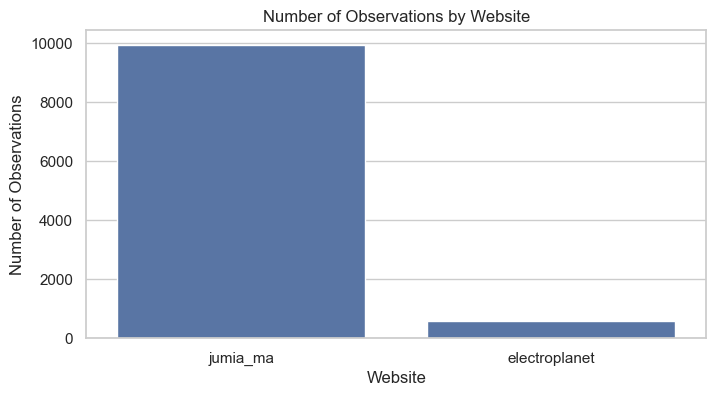

In [18]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="site_name", order=df_clean["site_name"].value_counts().index)
plt.title("Number of Observations by Website")
plt.xlabel("Website")
plt.ylabel("Number of Observations")
plt.show()

In [19]:
category_distribution = df_clean["category"].value_counts()
category_distribution

category
telephones-smartphones                  2711
peripheriques-logiciels-accessoires     1454
accessoires-telephone                   1240
tablettes-tactiles                      1123
electronique-accessoires-fournitures    1072
ordinateurs-pc                           840
ecrans-d-ordinateurs                     753
ordinateurs-accessoires-informatique     293
electronique                             252
telephone-tablette                       200
tablettes-android                        170
ecran                                    131
notebook                                 111
pc-gamer                                  46
macbook                                   36
adaptateurs                               34
pc-hybride                                30
ultrabook                                 27
Name: count, dtype: int64

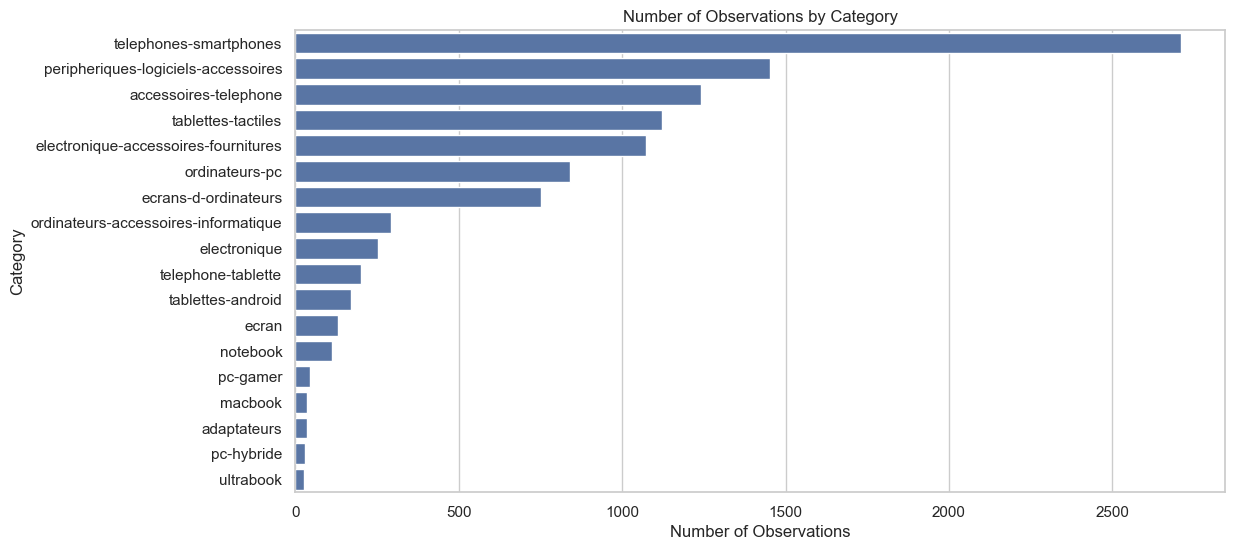

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_clean,
    y="category",
    order=df_clean["category"].value_counts().index
)
plt.title("Number of Observations by Category")
plt.xlabel("Number of Observations")
plt.ylabel("Category")
plt.show()

In [21]:
#Time coverage by product

product_time_coverage = df_ts.groupby("product_id").agg(
    nb_observations=("price", "count"),
    first_seen=("scraped_at", "min"),
    last_seen=("scraped_at", "max")
).reset_index()

product_time_coverage.head()

,product_id,nb_observations,first_seen,last_seen
0,ELECTRO-01EB89FF,1,2026-05-02 00:12:58.795706+00:00,2026-05-02 00:12:58.795706+00:00
1,ELECTRO-04677085,1,2026-05-02 00:12:36.671610+00:00,2026-05-02 00:12:36.671610+00:00
2,ELECTRO-04E8FF5F,2,2026-05-02 00:12:08.673198+00:00,2026-05-02 11:58:39.805042+00:00
3,ELECTRO-058A8739,2,2026-05-01 23:51:19.988432+00:00,2026-05-02 00:12:28.413307+00:00
4,ELECTRO-05A85AE1,1,2026-05-02 11:58:39.805076+00:00,2026-05-02 11:58:39.805076+00:00


In [22]:
#Time coverage by product

product_time_coverage = df_ts.groupby("product_id").agg(
    nb_observations=("price", "count"),
    first_seen=("scraped_at", "min"),
    last_seen=("scraped_at", "max")
).reset_index()

product_time_coverage

,product_id,nb_observations,first_seen,last_seen
0,ELECTRO-01EB89FF,1,2026-05-02 00:12:58.795706+00:00,2026-05-02 00:12:58.795706+00:00
1,ELECTRO-04677085,1,2026-05-02 00:12:36.671610+00:00,2026-05-02 00:12:36.671610+00:00
2,ELECTRO-04E8FF5F,2,2026-05-02 00:12:08.673198+00:00,2026-05-02 11:58:39.805042+00:00
3,ELECTRO-058A8739,2,2026-05-01 23:51:19.988432+00:00,2026-05-02 00:12:28.413307+00:00
4,ELECTRO-05A85AE1,1,2026-05-02 11:58:39.805076+00:00,2026-05-02 11:58:39.805076+00:00
...,...,...,...,...
929,JUMIA-FEBF78C6,27,2026-05-02 12:17:16.090875+00:00,2026-06-10 13:47:08.851530+00:00
930,JUMIA-FEFE662D,27,2026-05-02 12:17:16.083909+00:00,2026-06-10 13:47:08.840540+00:00
931,JUMIA-FF23350B,17,2026-05-02 12:28:34.509916+00:00,2026-05-26 00:33:59.851897+00:00
932,JUMIA-FF53BF7A,13,2026-05-25 09:58:40.751117+00:00,2026-05-26 00:22:24.192789+00:00


In [23]:
product_time_coverage["nb_observations"].describe()

count    934.000000
mean      11.266595
std        9.361080
min        1.000000
25%        3.000000
50%        7.000000
75%       19.000000
max       30.000000
Name: nb_observations, dtype: float64

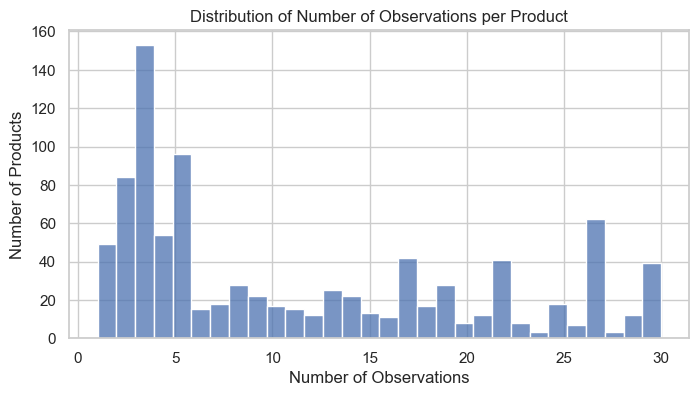

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(product_time_coverage["nb_observations"], bins=30)
plt.title("Distribution of Number of Observations per Product")
plt.xlabel("Number of Observations")
plt.ylabel("Number of Products")
plt.show()

In [25]:
#Quality summary

quality_summary = {
    "total_rows": len(df_clean),
    "missing_product_id": df_clean["product_id"].isna().sum(),
    "missing_price": df_clean["price"].isna().sum(),
    "missing_category": df_clean["category"].isna().sum(),
    "duplicate_rows": duplicate_rows,
    "business_duplicates": business_duplicates,
    "invalid_prices": len(invalid_prices),
    "unique_sites": df_clean["site_name"].nunique(),
    "unique_categories": df_clean["category"].nunique()
}

quality_summary

{'total_rows': 10523,
 'missing_product_id': np.int64(0),
 'missing_price': np.int64(0),
 'missing_category': np.int64(0),
 'duplicate_rows': np.int64(0),
 'business_duplicates': np.int64(0),
 'invalid_prices': 0,
 'unique_sites': 2,
 'unique_categories': 18}

In [26]:
#Markdown

"""The data quality validation confirms that the core analytical variables required for price analysis are complete. The dataset contains 10,523 rows, with no missing values in `product_id`, `price`, `category`, or `scraped_at`. No duplicate rows, business duplicates, or invalid prices were detected.

However, customer-related variables contain a high proportion of missing values: `rating` is missing in approximately 53.64% of observations, and `review_count` is missing in approximately 66.52% of observations. Therefore, inferential analyses involving ratings or review counts will be performed only on the subset of records where these variables are available, and their results should be interpreted carefully.

The time-series coverage varies across products. Each product has between 1 and 30 observations, with a median of 7 observations and an average of approximately 11.27 observations per product. This variation is expected in a scraping-based pipeline and should be considered when analyzing temporal price trends.

Missing values in `rating` and `review_count` are not removed at this stage because these variables are not required for the main price analysis. Removing all rows with missing customer feedback variables would significantly reduce the dataset and could introduce bias, especially because missingness is partly related to scraping limitations and product availability of ratings.

Therefore, the complete cleaned dataset is preserved for descriptive price analysis, temporal analysis, and website/category comparisons. For analyses involving `rating` or `review_count`, a dedicated subset containing only non-missing values will be created."""

'The data quality validation confirms that the core analytical variables required for price analysis are complete. The dataset contains 10,523 rows, with no missing values in `product_id`, `price`, `category`, or `scraped_at`. No duplicate rows, business duplicates, or invalid prices were detected.\n\nHowever, customer-related variables contain a high proportion of missing values: `rating` is missing in approximately 53.64% of observations, and `review_count` is missing in approximately 66.52% of observations. Therefore, inferential analyses involving ratings or review counts will be performed only on the subset of records where these variables are available, and their results should be interpreted carefully.\n\nThe time-series coverage varies across products. Each product has between 1 and 30 observations, with a median of 7 observations and an average of approximately 11.27 observations per product. This variation is expected in a scraping-based pipeline and should be considered when